In [1]:
!pip install pandas matplotlib
!python generate_data.py
!python analysis.py

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.5 MB 2.9 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.5 MB 2.8 MB/s eta 0:00:03
   --------- ------------------------------ 2.4/9.5 MB 2.7 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.5 MB 2.6 MB/s eta 0:00:03
   ------------ --------------------------- 2.9/9.5 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.5 MB 2.3 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.4 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.5 MB 2.4 MB/s eta 0:00:02
   ---------------------- ----------------- 5.2/9.5 MB 2.4 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 2.5 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.5 MB 2.5 MB/s eta 0:00:02
   ----------------

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('merchant_transactions.csv', parse_dates=['transaction_date'])
print(f"Loaded {len(df):,} rows")
df.head()

Loaded 50,300 rows


,transaction_id,merchant_id,category,region,channel,merchant_segment,transaction_date,amount,status
0,1,2126,Restaurant,East,Online,Small,2025-12-25,964.20,Approved
1,2,2459,Electronics,West,Online,Small,2026-03-30,6259.80,Approved
2,3,1860,Retail,South,Online,Small,2026-01-24,973.69,Approved
3,4,2294,Restaurant,North,In-Store,Large,2025-09-26,623.27,Approved
4,5,2130,Restaurant,East,Online,Large,2025-09-13,871.82,Approved


In [3]:
df.info()        # column types, non-null counts (spot the missing regions)
df.describe()    # numeric summary of amount
df['category'].value_counts()   # notice the messy UPPERCASE labels

<class 'pandas.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    50300 non-null  int64         
 1   merchant_id       50300 non-null  int64         
 2   category          50300 non-null  str           
 3   region            49292 non-null  str           
 4   channel           50300 non-null  str           
 5   merchant_segment  50300 non-null  str           
 6   transaction_date  50300 non-null  datetime64[us]
 7   amount            50300 non-null  float64       
 8   status            50300 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 3.5 MB


category
Retail         12928
Restaurant     11912
Grocery         9018
Electronics     5965
Travel          4901
Fuel            4822
RETAIL           198
RESTAURANT       183
GROCERY          131
ELECTRONICS      108
FUEL              67
TRAVEL            67
Name: count, dtype: int64

In [4]:
df = df.drop_duplicates(subset='transaction_id')
df['category'] = df['category'].str.title()
df['region'] = df['region'].fillna('Unknown')

df['is_declined'] = (df['status'] == 'Declined').astype(int)
df['approved_amount'] = df['amount'].where(df['status'] == 'Approved', 0)
print(f"After cleaning: {len(df):,} rows")

After cleaning: 50,000 rows


In [5]:
print(f"Approved revenue     : ${df['approved_amount'].sum():,.0f}")
print(f"Overall decline rate : {df['is_declined'].mean():.1%}")
print(f"Declined (lost) value: ${df.loc[df['status']=='Declined','amount'].sum():,.0f}")

Approved revenue     : $117,807,387
Overall decline rate : 11.0%
Declined (lost) value: $22,013,573


In [6]:
print("By category:")
print((df.groupby('category')['is_declined'].mean()*100).round(1).sort_values(ascending=False))
print("\nBy channel:")
print((df.groupby('channel')['is_declined'].mean()*100).round(1).sort_values(ascending=False))

By category:
category
Travel         29.8
Fuel            9.3
Electronics     9.1
Restaurant      8.9
Retail          8.9
Grocery         8.7
Name: is_declined, dtype: float64

By channel:
channel
Online      13.8
In-Store     9.0
Name: is_declined, dtype: float64


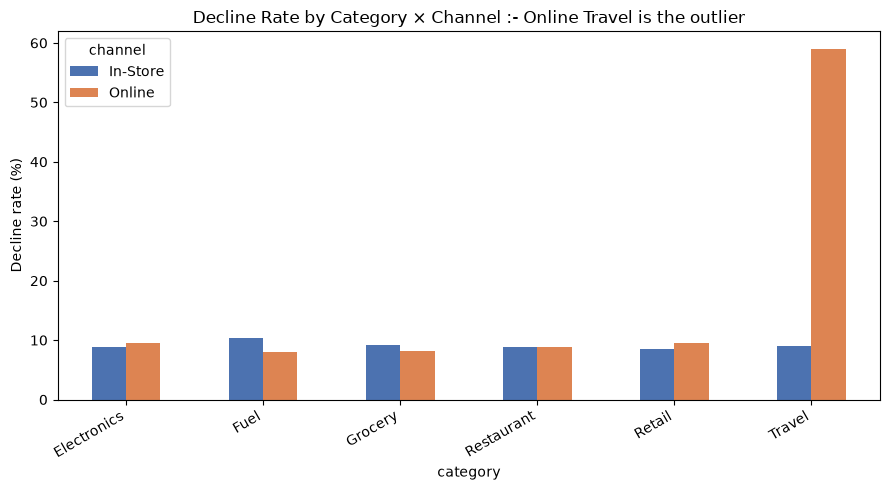

In [9]:
pivot = (df.pivot_table(index='category', columns='channel',
                        values='is_declined', aggfunc='mean')*100).round(1)

pivot.plot(kind='bar', figsize=(9,5), color=['#4C72B0','#DD8452'])
plt.ylabel('Decline rate (%)')
plt.title('Decline Rate by Category × Channel :- Online Travel is the outlier')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

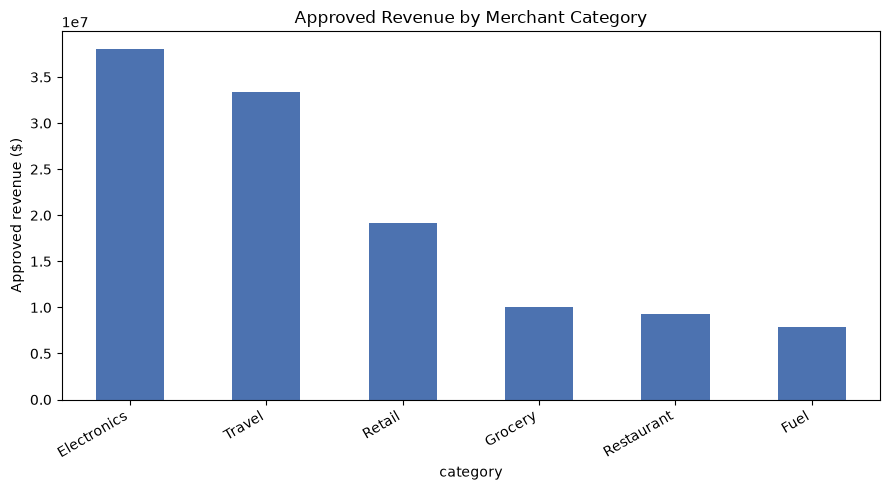

In [10]:
rev = df.groupby('category')['approved_amount'].sum().sort_values(ascending=False)
rev.plot(kind='bar', figsize=(9,5), color='#4C72B0')
plt.ylabel('Approved revenue ($)')
plt.title('Approved Revenue by Merchant Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

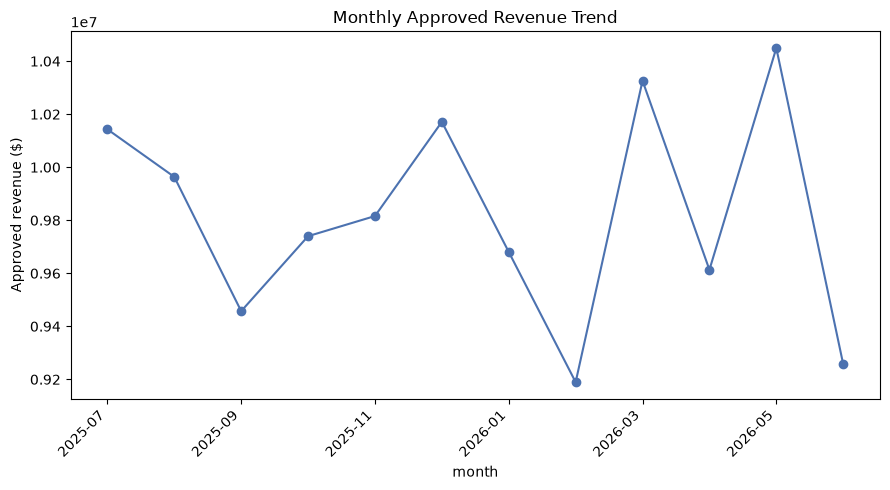

In [11]:
df['month'] = df['transaction_date'].dt.to_period('M').astype(str)
monthly = df.groupby('month')['approved_amount'].sum()
monthly.plot(kind='line', marker='o', figsize=(9,5), color='#4C72B0')
plt.ylabel('Approved revenue ($)')
plt.title('Monthly Approved Revenue Trend')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()